# Поверхностная аналитика

Описательные срезы по уже очищенным данным (раздел 7 плана). Читает `data/processed/`, ничего не пересчитывает и не перезаписывает.

> **Пересчитано 2026-09-05** после исправления методики премиум-сегмента (пункт 8.5.3: порог IQR считается внутри года, а не один на весь период). Везде, где ниже премиум исключается, состав выборки немного изменился — числа в выводах обновлены под новый расчёт, старые значения приведены рядом. Разбор самой ошибки — в ноутбуках очистки и в разделе 8.5 `deep_analysis.ipynb`.

In [1]:
import os
import sys

# Указание Директории
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Добавление корня проекта в sys.path (cwd уже переключён на корень)
sys.path.append(os.getcwd())
from src.price_factors import (
    rooms_distribution,
    price_by_building_year,
    price_effect_by_category,
    compare_category_across_segments,
    plot_category_effect,
    plot_price_by_class_okrug,
    BUILDING_TYPE_RU,
    RENOVATION_RU,
    COMPLEX_CLASS_RU,
    BOOL_RU,
)

import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd())
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'

df_rentals = pd.read_csv(PROCESSED_DIR / 'clean_rentals.csv')
df_secondary = pd.read_csv(PROCESSED_DIR / 'clean_secondary_market.csv')
df_new_builds = pd.read_csv(PROCESSED_DIR / 'clean_new_builds.csv')

print(f"Текущая директория: {os.getcwd()}")
print(f"Аренда: {len(df_rentals):,} | Вторичка: {len(df_secondary):,} | Новостройки: {len(df_new_builds):,}")

Текущая директория: D:\Moscow_rent_analysis
Аренда: 20,000 | Вторичка: 50,000 | Новостройки: 8,000


## 7.1 Распределение по числу комнат

In [2]:
table_rooms = rooms_distribution({
    'Аренда': df_rentals,
    'Вторичка': df_secondary,
    'Новостройки': df_new_builds,
})
print(table_rooms.to_string())

        Аренда, шт  Аренда, %  Вторичка, шт  Вторичка, %  Новостройки, шт  Новостройки, %
Комнат                                                                                   
0              0.0        0.0           0.0          0.0            797.0            10.0
1           9027.0       45.1       15041.0         30.1           2820.0            35.2
2           7008.0       35.0       19831.0         39.7           2823.0            35.3
3           3020.0       15.1       10024.0         20.0           1173.0            14.7
4            945.0        4.7        3550.0          7.1            387.0             4.8
5              0.0        0.0        1554.0          3.1              0.0             0.0


Три сегмента заметно отличаются по структуре предложения:

- **Аренда смещена в сторону малых квартир** — 80% предложения это 1-2 комнаты (45.1% однокомнатных). Крупных форматов почти нет: четырёхкомнатных 4.7%, пятикомнатных нет вообще.
- **Вторичка — самый "широкий" сегмент по форматам**: единственный, где встречаются пятикомнатные (3.1%), и заметно больше трёх- и четырёхкомнатных. Основная масса — двушки (39.7%).
- **Новостройки — единственный сегмент со студиями** (10% предложения, `rooms = 0`), при этом почти симметричны по 1- и 2-комнатным (35.2% и 35.3%).

Вывод: рынок аренды обслуживает в первую очередь спрос на компактное жильё, покупка вторички — семейный сегмент, а застройщики закрывают нишу самого дешёвого входа на рынок студиями, которых на вторичке нет вообще.

## Зависимость цены от года постройки дома

Премиум-сегмент и Новая Москва исключены — они образуют отдельные ценовые кластеры и сместили бы тренд по годам.

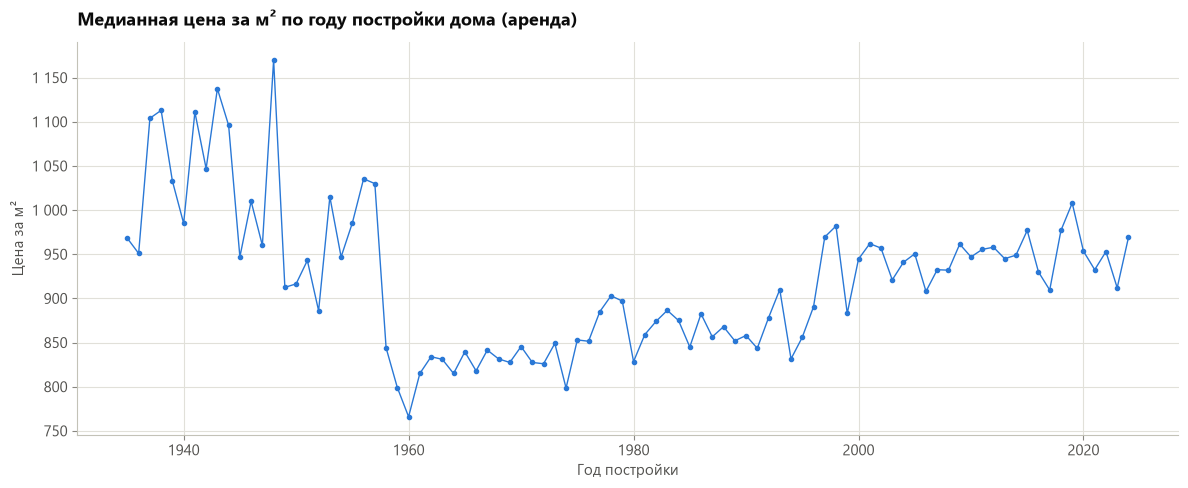

In [3]:
by_year_rentals = price_by_building_year(df_rentals, 'rent_per_sqm', 'аренда')

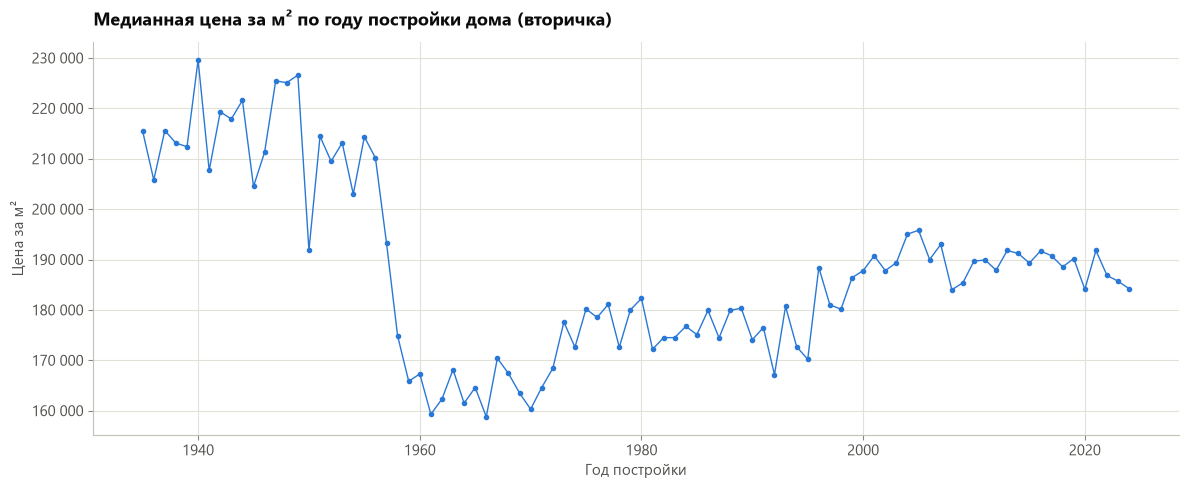

In [4]:
by_year_secondary = price_by_building_year(df_secondary, 'price_per_sqm', 'вторичка')

Оба графика дают одинаковую форму — и это не плавное удешевление с возрастом дома, как можно было ожидать, а **резкий обрыв на рубеже 1957-1960 годов**:

- Дома до 1957 года (сталинки) — самые дорогие в выборке: пик по аренде ~1 170 руб/м², по вторичке ~230 000 руб/м²
- В 1958-1960 цена падает почти отвесно, минимум приходится на 1960-1967 (хрущёвки): ~766 руб/м² по аренде, ~159 000 руб/м² по вторичке
- Дальше — медленное восстановление через 1970-1990-е и заметный подъём после ~1999 года, с выходом на плато в 2000-2020-х (~910-1 010 руб/м² и ~184-196 тыс. руб/м²)

**Разрыв между пиком сталинок и дном хрущёвок — +52.7% по аренде и +44.6% по вторичке**, то есть примерно в полтора раза, и он хорошо виден в обоих сегментах. То есть возраст дома сам по себе цену не определяет: дом 1950 года дороже дома 1965 года, хотя он старше. Определяет эпоха и тип застройки — качество, планировки, высота потолков, расположение застройки того периода.

## 7.2 Ремонт, мебель, животные (аренда)

In [5]:
columns_ru = {'renovation': 'Ремонт', 'furnished': 'Мебель', 'pets_allowed': 'Животные'}
labels_ru = {'renovation': RENOVATION_RU, 'furnished': BOOL_RU, 'pets_allowed': BOOL_RU}

for col in ['renovation', 'furnished', 'pets_allowed']:
    counts = df_rentals[col].value_counts().rename(index=labels_ru[col])
    shares = (counts / counts.sum() * 100).round(1)
    table = pd.DataFrame({'Объявлений, шт': counts, 'Доля, %': shares})
    table.index.name = columns_ru[col]
    print(f"\n=== {columns_ru[col]} ===")
    print(table.to_string())


=== Ремонт ===
               Объявлений, шт  Доля, %
Ремонт                                
Косметический            9035     45.2
Евроремонт               6959     34.8
Дизайнерский             2021     10.1
Без ремонта              1985      9.9

=== Мебель ===
        Объявлений, шт  Доля, %
Мебель                         
Да               14043     70.2
Нет               5957     29.8

=== Животные ===
          Объявлений, шт  Доля, %
Животные                         
Нет                13943     69.7
Да                  6057     30.3


### Влияние ремонта на цену

База для сравнения — жильё без ремонта (`no_renovation`).

In [6]:
print(price_effect_by_category(
    df_rentals, 'rent_per_sqm', 'renovation', baseline='no_renovation',
    labels=RENOVATION_RU, axis_name='Ремонт',
).to_string())

               Объявлений, шт  Медиана цены за м²  Разница к базе, %
Ремонт                                                              
Без ремонта              1615               762.0                0.0
Косметический            7205               838.0               10.0
Евроремонт               5327               955.0               25.3
Дизайнерский             1416              1095.0               43.7


### Влияние мебели на цену

База — жильё без мебели.

In [7]:
print(price_effect_by_category(
    df_rentals, 'rent_per_sqm', 'furnished', baseline=False,
    labels=BOOL_RU, axis_name='Мебель',
).to_string())

        Объявлений, шт  Медиана цены за м²  Разница к базе, %
Мебель                                                       
Нет               4687               850.0                0.0
Да               10876               916.0                7.8


### Влияние разрешения на животных

База — жильё, где животные запрещены.

In [8]:
print(price_effect_by_category(
    df_rentals, 'rent_per_sqm', 'pets_allowed', baseline=False,
    labels=BOOL_RU, axis_name='Животные',
).to_string())

          Объявлений, шт  Медиана цены за м²  Разница к базе, %
Животные                                                       
Да                  4745               880.0               -2.5
Нет                10818               903.0                0.0


Итог по трём факторам аренды (везде без премиум-сегмента и Новой Москвы, база — худший вариант признака):

| Фактор | Надбавка к цене за м² |
|---|---|
| Косметический ремонт | +10.0% |
| Евроремонт | +25.3% |
| Дизайнерский ремонт | +43.7% |
| Мебель | +7.8% |
| Разрешены животные | **−2.5%** |

- **Ремонт — самый сильный из трёх факторов и работает строго монотонно**: каждая следующая ступень качества ремонта прибавляет к цене, дизайнерский ремонт стоит почти в полтора раза дороже жилья без ремонта.
- **Мебель прибавляет скромные 7.8%** — притом что мебель есть у 70.2% объявлений, то есть это уже норма рынка, а не преимущество.
- **Разрешение на животных даёт минус 2.5%** — контринтуитивно на первый взгляд. Скорее всего, это не "скидка за питомцев", а обратная зависимость: собственники более дорогого жилья реже готовы пускать с животными (животных разрешают только в 30.3% объявлений), поэтому в группе "разрешено" оказывается в среднем более простое жильё. Проверить эту гипотезу можно только с поправкой на прочие факторы — это уже задача регрессии из раздела 8.

## 7.3 Цена по типу дома

`building_type` есть только в аренде и вторичке — у новостроек вместо него `complex_class` (разбираем его в 7.4). База для сравнения — хрущёвка, самый дешёвый тип по итогам 7.1. Премиум-сегмент и Новая Москва исключены.

In [9]:
table_building_type = compare_category_across_segments(
    {
        'Аренда': (df_rentals, 'rent_per_sqm'),
        'Вторичка': (df_secondary, 'price_per_sqm'),
    },
    category_col='building_type',
    baseline='khrushchev',
    labels=BUILDING_TYPE_RU,
    axis_name='Тип дома',
)
print(table_building_type.to_string())

              Аренда, шт  Аренда, медиана  Аренда, % к базе  Вторичка, шт  Вторичка, медиана  Вторичка, % к базе
Тип дома                                                                                                        
Хрущёвка            2442            779.0               0.0          6056           157200.0                 0.0
Панель              3944            839.0               7.7          7994           168650.0                 7.3
Совр. панель        2623            892.0              14.5          7731           182200.0                15.9
Кирпич              2798            942.0              20.9          6760           189100.0                20.3
Монолит             3028            983.0              26.2          7672           197950.0                25.9
Сталинка             728           1034.0              32.7          2594           217050.0                38.1


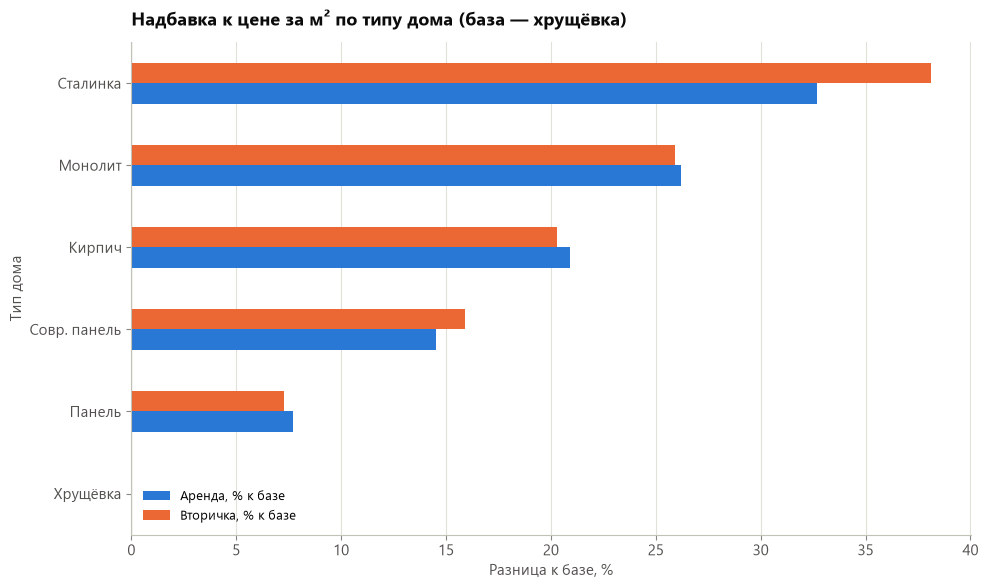

In [10]:
plot_category_effect(table_building_type, 'Надбавка к цене за м² по типу дома (база — хрущёвка)')

Порядок типов домов по цене **полностью совпадает в аренде и во вторичке**, и сами проценты почти идентичны:

| Тип дома | Аренда | Вторичка |
|---|---|---|
| Хрущёвка (база) | 0% | 0% |
| Панель | +7.7% | +7.3% |
| Современная панель | +14.5% | +15.9% |
| Кирпич | +20.9% | +20.3% |
| Монолит | +26.2% | +25.9% |
| Сталинка | +32.7% | **+38.1%** |

Два наблюдения:

1. **Совпадение порядка и величин в двух независимых сегментах** — сильный признак, что это устойчивая закономерность рынка, а не случайность выборки: расхождение по большинству типов меньше одного процентного пункта.
2. **Сталинки — единственное исключение**: при покупке за них доплачивают заметно больше, чем при аренде (+38.1% против +32.7%). Логично: покупатель платит за качество и престиж самого дома, тогда как арендатору важнее сама квартира, а не статус здания.

Это же объясняет обрыв на графике по годам постройки из 7.1 — провал 1958-1960 годов и есть переход от сталинок (+33-38%) к хрущёвкам (база, самый дешёвый тип).

## 7.4 Класс новостроек по округам

Здесь Новая Москва и премиум-сегмент **не** исключаются, в отличие от предыдущих пунктов: сам смысл разреза — география, а TAO/NAO/ZelAO это три из одиннадцати округов, без них картина была бы неполной.

Сначала считаем, сколько объявлений каждого класса в каждом округе, потом — медианную цену за м² для каждой пары «класс × округ».

In [11]:
class_order = ['Эконом', 'Комфорт', 'Бизнес', 'Премиум']

counts_class_okrug = pd.crosstab(df_new_builds['okrug'], df_new_builds['complex_class'])
counts_class_okrug = counts_class_okrug.rename(columns=COMPLEX_CLASS_RU)[class_order]
counts_class_okrug.columns.name = 'Класс'
counts_class_okrug.index.name = 'Округ'

print("=== Количество объявлений: округ × класс ===")
print(counts_class_okrug.to_string())

=== Количество объявлений: округ × класс ===


Класс  Эконом  Комфорт  Бизнес  Премиум
Округ                                  
CAO       319      253      72        0
NAO       212      256     231       56
SAO       215      354     293       26
SVAO      384      415      56        0
SZAO      317       89     187       68
TAO       189      435      92       35
VAO       487      444     372       60
YuAO      190      323     119       53
YuZAO     114      437     197       32
ZAO       118      239     129        0
ZelAO      63       69       0        0


In [12]:
price_class_okrug = df_new_builds.pivot_table(
    index='okrug',
    columns='complex_class',
    values='price_per_sqm',
    aggfunc='median',
).round(0)
price_class_okrug = price_class_okrug.rename(columns=COMPLEX_CLASS_RU)[class_order]
price_class_okrug.columns.name = 'Класс'
price_class_okrug.index.name = 'Округ'

print("=== Медианная цена за м²: округ × класс ===")
print(price_class_okrug.to_string())

=== Медианная цена за м²: округ × класс ===
Класс    Эконом   Комфорт    Бизнес   Премиум
Округ                                        
CAO    399000.0  529500.0  589500.0       NaN
NAO    123400.0  135250.0  206200.0  324000.0
SAO    194100.0  248350.0  288600.0  410150.0
SVAO   185700.0  206100.0  314850.0       NaN
SZAO   227900.0  249400.0  397500.0  505150.0
TAO     71800.0   85200.0  114550.0  163300.0
VAO    175400.0  214000.0  315150.0  448050.0
YuAO   162100.0  226700.0  313900.0  465800.0
YuZAO  247100.0  268900.0  418300.0  596850.0
ZAO    224850.0  313600.0  344500.0       NaN
ZelAO  113700.0  133100.0       NaN       NaN


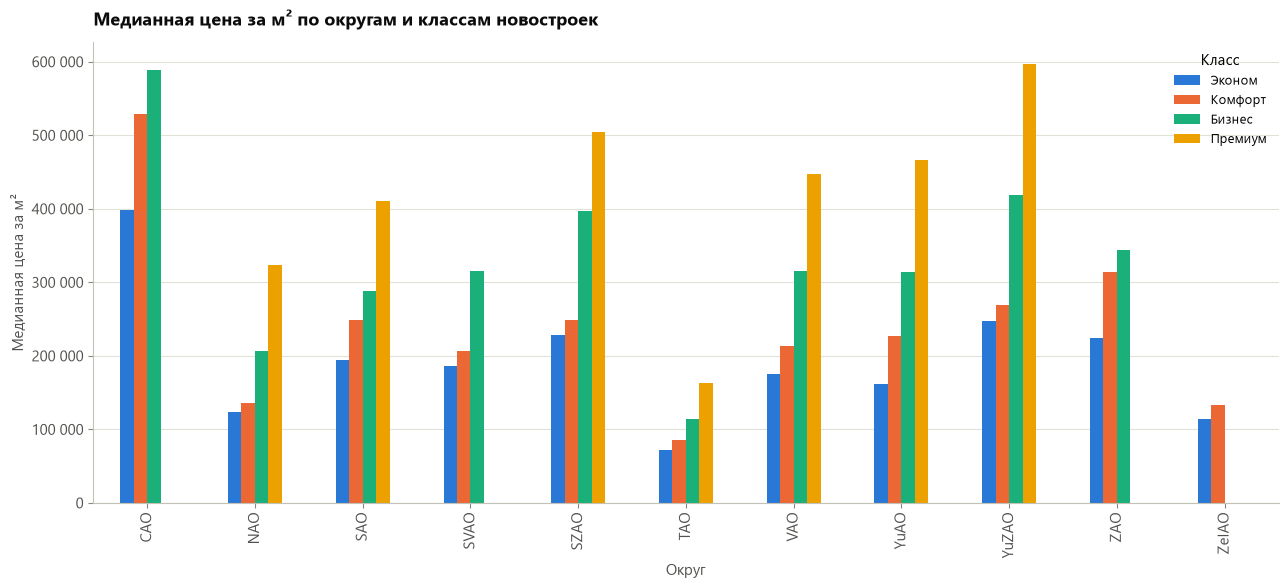

In [13]:
plot_price_by_class_okrug(price_class_okrug, 'Медианная цена за м² по округам и классам новостроек')

### Где какой класс и почём

**Главный вывод: класс жилья определяет цену намного слабее, чем округ.**

Достаточно сравнить две цифры из таблицы: economy-класс в ЦАО стоит 399 000 руб/м², а premium-класс в ТАО — 163 300 руб/м². Самый дешёвый класс в центре в **2.4 раза дороже** самого дорогого класса в Новой Москве.

Ещё нагляднее разброс внутри одного класса: economy стоит от 71 800 руб/м² в ТАО до 399 000 руб/м² в ЦАО — **разница в 5.6 раза при одинаковой формальной категории жилья**. Для сравнения, разброс между классами внутри одного округа гораздо скромнее: в ЦАО business/economy = 1.5 раза, в ТАО premium/economy = 2.3 раза.

Отдельно по географии:

- **ЦАО — самый дорогой округ по всем классам**, которые в нём есть (business 589 500, comfort 529 500, economy 399 000)
- **ТАО — самый дешёвый** по всем классам (economy 71 800, premium 163 300)
- **Premium-класса вообще нет в ЦАО, СВАО, ЗАО и Зеленограде** — при том что ЦАО лидирует по ценам. То есть застройщики не маркируют центральные проекты как «премиум», хотя по деньгам они таковыми и являются
- Самая высокая цена премиума — в ЮЗАО (596 850), даже выше самого дорогого класса в ЦАО

Это прямо объясняет находку из п.6.3 — почему economy-класс попадал в премиум-**ценовой** сегмент: речь шла именно о центральных объектах эконом-класса, где локация перевешивает категорию.

**Оговорка по данным:** в некоторых парах мало объявлений (premium в САО — 26 шт, в ЮЗАО — 32, в ТАО — 35), медиана по ним менее устойчива, чем по крупным группам. Ячейки без значения (NaN) означают, что таких объявлений в датасете нет вообще.